In [1]:
# input
rep_go_terms = "../data/rep_go_terms.tsv"
go_obo_file = "../../../_database/go/go.obo"
go_slim_file = "../../../_database/go/goslim_generic.obo"
# output
fig_file = "./fig/rep_go_terms_distribution.pdf"

In [2]:
import pandas as pd
from collections import Counter
from goatools.obo_parser import GODag
from goatools.mapslim import mapslim

# 1. 加载完整的 OBO 和 Slim OBO
go_dag = GODag(go_obo_file, prt=None)
slim_dag = GODag(go_slim_file, prt=None)

# 2. 读取数据 (假设您的文件名为 rep_go_terms.tsv)
df = pd.read_table(rep_go_terms, header=None, names=["seq_id", "gos"])

mapped_results = []

for _, row in df.iterrows():
    # 使用 set() 去除单条序列内部重复的 GO term，避免统计偏差
    raw_gos = set(row['gos'].split(";"))
    
    # 存储该蛋白映射后的 Slim GOs
    protein_slim_set = set()
    
    for go_id in raw_gos:
        if go_id in go_dag:
            # 使用 mapslim 函数进行映射
            # direct_anc: 直接的 slim 祖先；all_anc: 所有的 slim 祖先
            direct_anc, all_anc = mapslim(go_id, go_dag, slim_dag)
            
            # 我们通常取 all_anc 中属于 molecular_function 的部分
            for slim_go in all_anc:
                if slim_dag[slim_go].namespace == "molecular_function" and slim_dag[slim_go].level == 1:
                    protein_slim_set.add(slim_go)
    
    mapped_results.extend(list(protein_slim_set))

# 3. 统计并展示
data = []
counter = Counter(mapped_results)
for go_id, count in counter.most_common(10):
    print(f"{go_id}\t{count}\t{slim_dag[go_id].name}")
    data.append((go_id, count, slim_dag[go_id].name))

GO:0016787	7306	hydrolase activity
GO:0016740	5560	transferase activity
GO:0140096	2650	catalytic activity, acting on a protein
GO:0016491	2358	oxidoreductase activity
GO:0140098	1572	catalytic activity, acting on RNA
GO:0140097	1314	catalytic activity, acting on DNA
GO:0016829	1038	lyase activity
GO:0016853	984	isomerase activity
GO:0016874	543	ligase activity
GO:0140299	178	molecular sensor activity


<Figure size 160x160 with 0 Axes>

(0.0, 8000.0)

<BarContainer object of 10 artists>

Text(0.5, 0, 'Count')

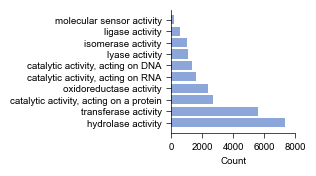

In [4]:
import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
plt.figure(figsize=(1.6, 1.6))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x = [i[2] for i in data]
y = [i[1] for i in data]


ax.set_xlim(0, 8000)
plt.barh(x, y)
plt.xlabel('Count')
plt.savefig(fig_file, bbox_inches="tight", transparent=True)